# 05. AI-Assisted DAG Brainstorming

Notebook 04 turned causal questions into estimand cards and design documents. This notebook moves one layer deeper: we use AI to brainstorm candidate directed acyclic graphs, or DAGs, from a design brief.

A DAG is not decoration. It is a compact statement of causal assumptions. It says which variables are causes, which variables are downstream consequences, which paths create confounding, and which variables should not be controlled for.

The AI role is limited but valuable: it can help generate candidate variables, plausible causal links, and questions for domain experts. The analyst's job is to challenge those suggestions, enforce time ordering, and decide which assumptions are credible.


## Learning Goals

By the end of this notebook, you should be able to:

- explain why a DAG is an assumption document rather than a discovered truth;
- use a project brief to brainstorm candidate variables and causal links;
- distinguish confounders, mediators, selection variables, guardrails, and measurement variables;
- render candidate DAGs with Graphviz;
- check a proposed DAG for cycles and obvious role conflicts;
- use simulation to show why brainstormed confounders matter;
- use LLMs to draft DAG artifacts while keeping validation, semantic review, and human judgment in the loop;
- compare all available local models on structured DAG-brainstorm reliability and design quality.


## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal inference requires validation, audit trails, and analyst judgment.

Treat model output as a draft artifact, not as causal evidence. A model may produce valid JSON with weak causal reasoning, or strong prose that fails schema validation.

When live calls are enabled, read the results as experiments about AI behavior:

- Did the model invent design details?
- Did it confuse prediction with causation?
- Did it recommend bad controls?
- Did it obey the schema?
- Did it surface missing information?
- Did it preserve uncertainty?

The goal is not to make every model output perfect. The goal is to learn how to build AI-assisted causal workflows that are auditable, constrained, and reviewed by a human analyst.

## 1. Setup


In [1]:
import gc
import importlib.util
import json
import re
import textwrap
from functools import lru_cache
from typing import Literal

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from graphviz import Digraph
from IPython.display import Markdown, display
from pydantic import BaseModel, Field, ValidationError

pd.set_option('display.max_colwidth', 150)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', context='notebook')


In [2]:
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'

LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_FAST_MODEL
MAX_NEW_TOKENS = 2400
TEMPERATURE = 0.0
SEED = 42

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]


In [3]:
def has_package(module_name):
    return importlib.util.find_spec(module_name) is not None

runtime_status = pd.DataFrame(
    [
        ('torch', torch.__version__),
        ('cuda available', torch.cuda.is_available()),
        ('cuda device count', torch.cuda.device_count()),
        ('graphviz python package', has_package('graphviz')),
        ('networkx installed', has_package('networkx')),
        ('accelerate installed', has_package('accelerate')),
        ('transformers installed', has_package('transformers')),
        ('torchvision installed', has_package('torchvision')),
    ],
    columns=['check', 'value'],
)

runtime_status


,check,value
0,torch,2.11.0+cu130
1,cuda available,True
2,cuda device count,1
3,graphviz python package,True
4,networkx installed,True
5,accelerate installed,True
6,transformers installed,True
7,torchvision installed,True


## 2. What a DAG Is For

A DAG is a directed graph with no directed cycles. In causal inference, we use it to encode assumptions about how variables cause one another.

DAGs help answer questions such as:

- What variables may confound the treatment-outcome relationship?
- Which variables are downstream consequences of treatment?
- Which variables are colliders that should not be conditioned on?
- Which variables are measurement artifacts rather than causes of the true outcome?
- What domain assumptions must be reviewed before estimation?

The important mindset is this: **a DAG is not automatically true because it is drawn neatly.** It is a hypothesis about the data-generating process. AI can help brainstorm that hypothesis, but it cannot make the assumptions valid by sounding confident.


In [4]:
dag_vocabulary = pd.DataFrame(
    [
        ('treatment', 'Intervention or exposure whose effect we want', 'assistant_enabled'),
        ('outcome', 'Primary result measured after treatment', 'human_handled_ticket_workload'),
        ('confounder', 'Pre-treatment cause of both treatment and outcome', 'queue_volume, readiness, staffing'),
        ('mediator', 'Post-treatment pathway from treatment to outcome', 'agent_adoption, ticket_deflection'),
        ('selection', 'Variable controlling which units enter the observed data', 'eligible_queue'),
        ('measurement', 'Logging or measurement process that changes observed variables', 'deflection_logging'),
        ('guardrail', 'Secondary outcome that can block launch', 'reopen_rate, CSAT'),
        ('forbidden control', 'Variable that should not be adjusted for in the target analysis', 'post-treatment adoption'),
    ],
    columns=['role', 'definition', 'example'],
)

dag_vocabulary


,role,definition,example
0,treatment,Intervention or exposure whose effect we want,assistant_enabled
1,outcome,Primary result measured after treatment,human_handled_ticket_workload
2,confounder,Pre-treatment cause of both treatment and outcome,"queue_volume, readiness, staffing"
3,mediator,Post-treatment pathway from treatment to outcome,"agent_adoption, ticket_deflection"
4,selection,Variable controlling which units enter the observed data,eligible_queue
5,measurement,Logging or measurement process that changes observed variables,deflection_logging
6,guardrail,Secondary outcome that can block launch,"reopen_rate, CSAT"
7,forbidden control,Variable that should not be adjusted for in the target analysis,post-treatment adoption


## 3. Running Example: AI Support Assistant Rollout


In [5]:
project_brief = textwrap.dedent(
    '''
    The support organization is considering whether to expand an AI assistant to all eligible support queues.
    The assistant helps with triage and first-draft responses. Early rollout was prioritized for queues with high ticket volume,
    higher operational readiness, and managers who requested the tool. Leadership wants to know whether assistant enablement
    reduces human-handled ticket workload without harming reopen rates or customer satisfaction.

    Important operational details:
    - Queues differ in baseline incoming demand, staffing, backlog, complexity, and customer mix.
    - Operational readiness affects whether a queue receives the assistant early and may also affect outcomes.
    - Some queues changed routing rules during the rollout period.
    - The assistant may reduce measured ticket workload by deflecting tickets before a human touches them.
    - Deflection logging and first-contact resolution definitions changed in some queues.
    - Reopen rate and CSAT are guardrails, not primary workload outcomes.
    '''
).strip()

print(project_brief)


The support organization is considering whether to expand an AI assistant to all eligible support queues.
The assistant helps with triage and first-draft responses. Early rollout was prioritized for queues with high ticket volume,
higher operational readiness, and managers who requested the tool. Leadership wants to know whether assistant enablement
reduces human-handled ticket workload without harming reopen rates or customer satisfaction.

Important operational details:
- Queues differ in baseline incoming demand, staffing, backlog, complexity, and customer mix.
- Operational readiness affects whether a queue receives the assistant early and may also affect outcomes.
- Some queues changed routing rules during the rollout period.
- The assistant may reduce measured ticket workload by deflecting tickets before a human touches them.
- Deflection logging and first-contact resolution definitions changed in some queues.
- Reopen rate and CSAT are guardrails, not primary workload outcomes.


## 4. From Brief to Candidate Variables

A useful DAG brainstorming workflow begins by extracting variables before drawing arrows. This reduces the chance that the model jumps directly to a persuasive but under-specified graph.

For each variable, we want at least four pieces of information: what the variable means, when it is measured relative to treatment, whether it is observed, and what role it might play in the DAG.


In [6]:
variable_catalog = pd.DataFrame(
    [
        ('queue_volume', 'Baseline ticket volume before rollout', 'pre-treatment', True, 'confounder'),
        ('operational_readiness', 'Technical and managerial readiness to adopt the assistant', 'pre-treatment', True, 'confounder'),
        ('staffing_level', 'Number and skill mix of support agents', 'pre-treatment', True, 'confounder'),
        ('baseline_backlog', 'Open ticket backlog before rollout', 'pre-treatment', True, 'confounder'),
        ('queue_complexity', 'Technical complexity and customer mix', 'pre-treatment', 'partially', 'confounder'),
        ('routing_change', 'Concurrent routing or process redesign', 'pre-treatment or concurrent', True, 'confounder'),
        ('assistant_enabled', 'Assistant enabled for triage and draft responses', 'treatment', True, 'treatment'),
        ('agent_adoption', 'Actual usage intensity by support agents', 'post-treatment', True, 'mediator'),
        ('ticket_deflection', 'Tickets resolved or redirected before human handling', 'post-treatment', 'partially', 'mediator/measurement'),
        ('deflection_logging', 'Whether deflection events are measured consistently', 'post-treatment', True, 'measurement'),
        ('human_handled_workload', 'Human-handled tickets per queue-day adjusted for demand', 'post-treatment', True, 'outcome'),
        ('reopen_rate', 'Share of resolved tickets reopened within 7 days', 'post-treatment', True, 'guardrail'),
        ('csat', 'Customer satisfaction after support interaction', 'post-treatment', True, 'guardrail'),
        ('eligible_queue', 'Queue enters rollout-eligible data', 'selection', True, 'selection'),
    ],
    columns=['variable', 'description', 'timing', 'observed', 'candidate_role'],
)

variable_catalog


,variable,description,timing,observed,candidate_role
0,queue_volume,Baseline ticket volume before rollout,pre-treatment,True,confounder
1,operational_readiness,Technical and managerial readiness to adopt the assistant,pre-treatment,True,confounder
2,staffing_level,Number and skill mix of support agents,pre-treatment,True,confounder
3,baseline_backlog,Open ticket backlog before rollout,pre-treatment,True,confounder
4,queue_complexity,Technical complexity and customer mix,pre-treatment,partially,confounder
5,routing_change,Concurrent routing or process redesign,pre-treatment or concurrent,True,confounder
6,assistant_enabled,Assistant enabled for triage and draft responses,treatment,True,treatment
7,agent_adoption,Actual usage intensity by support agents,post-treatment,True,mediator
8,ticket_deflection,Tickets resolved or redirected before human handling,post-treatment,partially,mediator/measurement
9,deflection_logging,Whether deflection events are measured consistently,post-treatment,True,measurement


## 5. A Structured DAG Brainstorm Schema

We will ask the model for a structured DAG brainstorm, not a final graph. The schema forces the output to separate nodes, edges, adjustment candidates, forbidden controls, open questions, and assumptions to review.


In [7]:
NODE_ROLES = {
    'treatment', 'outcome', 'confounder', 'mediator', 'collider', 'selection',
    'instrument', 'guardrail', 'measurement', 'post_treatment', 'context', 'unknown',
}
EDGE_CONFIDENCE = {'low', 'medium', 'high'}

class DAGNode(BaseModel):
    node_id: str
    label: str
    role: Literal['treatment', 'outcome', 'confounder', 'mediator', 'collider', 'selection', 'instrument', 'guardrail', 'measurement', 'post_treatment', 'context', 'unknown']
    timing: str
    observed: bool | str
    description: str

class DAGEdge(BaseModel):
    source: str
    target: str
    rationale: str
    confidence: Literal['low', 'medium', 'high'] = 'medium'

class DAGBrainstorm(BaseModel):
    graph_id: str
    project_question: str
    treatment_node: str
    outcome_node: str
    nodes: list[DAGNode] = Field(min_length=2)
    edges: list[DAGEdge] = Field(default_factory=list)
    adjustment_candidates: list[str] = Field(default_factory=list)
    forbidden_controls: list[str] = Field(default_factory=list)
    unresolved_questions: list[str] = Field(default_factory=list)
    assumptions_to_review: list[str] = Field(default_factory=list)


## 6. Analyst-Seeded Candidate DAG


In [8]:
node_records = [
    ('queue_volume', 'Baseline queue volume', 'confounder', 'pre-treatment', True, 'Historical incoming ticket volume before rollout.'),
    ('operational_readiness', 'Operational readiness', 'confounder', 'pre-treatment', True, 'Technical readiness and managerial capacity to adopt the assistant.'),
    ('staffing_level', 'Staffing level', 'confounder', 'pre-treatment', True, 'Agent staffing and experience before rollout.'),
    ('baseline_backlog', 'Baseline backlog', 'confounder', 'pre-treatment', True, 'Open ticket backlog before rollout.'),
    ('queue_complexity', 'Queue complexity', 'confounder', 'pre-treatment', 'partially', 'Issue complexity and customer mix.'),
    ('routing_change', 'Routing change', 'confounder', 'concurrent', True, 'Process redesign that may affect rollout and workload.'),
    ('assistant_enabled', 'Assistant enabled', 'treatment', 'treatment', True, 'AI assistant enabled for queue triage and first-draft responses.'),
    ('agent_adoption', 'Agent adoption', 'mediator', 'post-treatment', True, 'How much agents actually use the assistant.'),
    ('ticket_deflection', 'Ticket deflection', 'mediator', 'post-treatment', 'partially', 'Tickets resolved or redirected before human handling.'),
    ('deflection_logging', 'Deflection logging', 'measurement', 'post-treatment', True, 'Whether deflection is consistently logged after rollout.'),
    ('human_handled_workload', 'Human-handled workload', 'outcome', 'post-treatment', True, 'Human-handled tickets per queue-day adjusted for demand.'),
    ('reopen_rate', 'Reopen rate', 'guardrail', 'post-treatment', True, 'Share of resolved tickets reopened within 7 days.'),
    ('csat', 'Customer satisfaction', 'guardrail', 'post-treatment', True, 'Customer satisfaction after support interaction.'),
    ('eligible_queue', 'Eligible queue', 'selection', 'pre-treatment', True, 'Queue is included in the rollout-eligible analysis population.'),
]

edge_records = [
    ('queue_volume', 'assistant_enabled', 'High-volume queues were prioritized for early assistant rollout.', 'high'),
    ('queue_volume', 'human_handled_workload', 'Baseline demand predicts later human-handled workload.', 'high'),
    ('operational_readiness', 'assistant_enabled', 'Ready queues were easier to deploy.', 'high'),
    ('operational_readiness', 'human_handled_workload', 'Readier queues may have better operations independent of the assistant.', 'medium'),
    ('staffing_level', 'assistant_enabled', 'Better-staffed queues may be more likely to adopt the assistant.', 'medium'),
    ('staffing_level', 'human_handled_workload', 'Staffing changes work capacity and queue handling.', 'high'),
    ('baseline_backlog', 'assistant_enabled', 'Backlogged queues may request or receive AI assistance.', 'medium'),
    ('baseline_backlog', 'human_handled_workload', 'Backlog predicts future workload.', 'high'),
    ('queue_complexity', 'assistant_enabled', 'Complex queues may be prioritized or delayed.', 'medium'),
    ('queue_complexity', 'human_handled_workload', 'Complex queues take more human effort.', 'high'),
    ('routing_change', 'assistant_enabled', 'Routing redesign can coincide with assistant rollout.', 'medium'),
    ('routing_change', 'human_handled_workload', 'Routing changes can alter measured workload.', 'high'),
    ('assistant_enabled', 'agent_adoption', 'Enablement makes agent adoption possible.', 'high'),
    ('assistant_enabled', 'ticket_deflection', 'Assistant may deflect tickets before human handling.', 'medium'),
    ('assistant_enabled', 'deflection_logging', 'Enablement can change what is logged as deflection.', 'medium'),
    ('agent_adoption', 'human_handled_workload', 'Adoption is a pathway through which enablement changes workload.', 'high'),
    ('ticket_deflection', 'human_handled_workload', 'Deflected tickets reduce measured human-handled workload.', 'high'),
    ('deflection_logging', 'human_handled_workload', 'Logging can change measured workload even if true demand is unchanged.', 'medium'),
    ('assistant_enabled', 'reopen_rate', 'Assistant quality may affect reopened tickets.', 'medium'),
    ('assistant_enabled', 'csat', 'Assistant quality may affect customer satisfaction.', 'medium'),
    ('eligible_queue', 'assistant_enabled', 'Only eligible queues can receive the assistant.', 'high'),
    ('eligible_queue', 'human_handled_workload', 'Eligibility restrictions define which queues are observed in the study.', 'medium'),
]

manual_dag = DAGBrainstorm.model_validate(
    {
        'graph_id': 'ai_support_candidate_dag_v1',
        'project_question': 'What is the causal effect of enabling the AI support assistant on human-handled ticket workload?',
        'treatment_node': 'assistant_enabled',
        'outcome_node': 'human_handled_workload',
        'nodes': [
            {'node_id': node_id, 'label': label, 'role': role, 'timing': timing, 'observed': observed, 'description': description}
            for node_id, label, role, timing, observed, description in node_records
        ],
        'edges': [
            {'source': source, 'target': target, 'rationale': rationale, 'confidence': confidence}
            for source, target, rationale, confidence in edge_records
        ],
        'adjustment_candidates': ['queue_volume', 'operational_readiness', 'staffing_level', 'baseline_backlog', 'queue_complexity', 'routing_change'],
        'forbidden_controls': ['agent_adoption', 'ticket_deflection', 'deflection_logging', 'reopen_rate', 'csat'],
        'unresolved_questions': [
            'Was rollout timing driven by unobserved manager urgency?',
            'Did routing changes occur before or after assistant enablement?',
            'Can ticket deflection be measured consistently across queues?',
        ],
        'assumptions_to_review': [
            'All major pre-treatment common causes of rollout and workload are observed.',
            'Post-treatment adoption and deflection should not be controlled for when estimating the total effect of enablement.',
            'Eligibility should define the population rather than become a post-treatment conditioning variable.',
        ],
    }
)

manual_dag


DAGBrainstorm(graph_id='ai_support_candidate_dag_v1', project_question='What is the causal effect of enabling the AI support assistant on human-handled ticket workload?', treatment_node='assistant_enabled', outcome_node='human_handled_workload', nodes=[DAGNode(node_id='queue_volume', label='Baseline queue volume', role='confounder', timing='pre-treatment', observed=True, description='Historical incoming ticket volume before rollout.'), DAGNode(node_id='operational_readiness', label='Operational readiness', role='confounder', timing='pre-treatment', observed=True, description='Technical readiness and managerial capacity to adopt the assistant.'), DAGNode(node_id='staffing_level', label='Staffing level', role='confounder', timing='pre-treatment', observed=True, description='Agent staffing and experience before rollout.'), DAGNode(node_id='baseline_backlog', label='Baseline backlog', role='confounder', timing='pre-treatment', observed=True, description='Open ticket backlog before rollout.

## 7. Graphviz Rendering


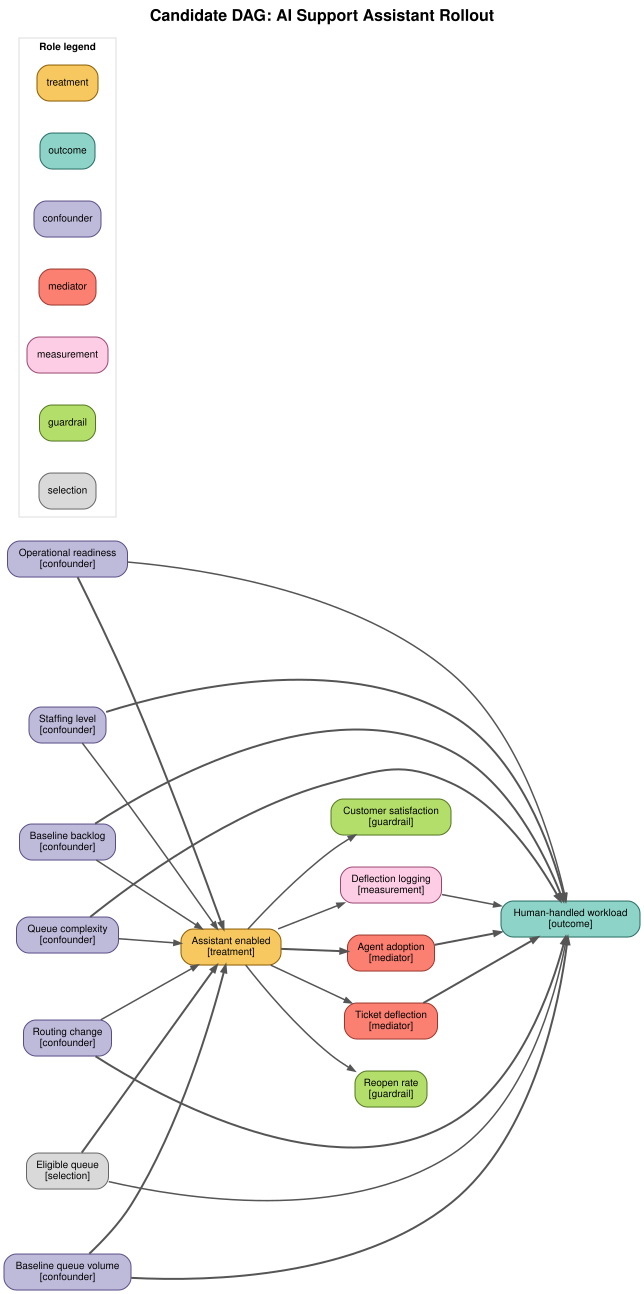

In [9]:
ROLE_STYLES = {
    'treatment': {'fillcolor': '#f6c85f', 'color': '#8a5a00'},
    'outcome': {'fillcolor': '#8dd3c7', 'color': '#246b61'},
    'confounder': {'fillcolor': '#bebada', 'color': '#5a4d87'},
    'mediator': {'fillcolor': '#fb8072', 'color': '#9d352b'},
    'guardrail': {'fillcolor': '#b3de69', 'color': '#52751f'},
    'measurement': {'fillcolor': '#fccde5', 'color': '#9b4772'},
    'selection': {'fillcolor': '#d9d9d9', 'color': '#666666'},
    'context': {'fillcolor': '#ccebc5', 'color': '#4e7f47'},
    'collider': {'fillcolor': '#bc80bd', 'color': '#6f3d70'},
    'instrument': {'fillcolor': '#80b1d3', 'color': '#2e6385'},
    'post_treatment': {'fillcolor': '#fdb462', 'color': '#9a5f1d'},
    'unknown': {'fillcolor': '#eeeeee', 'color': '#777777'},
}


def short_label(text, width=22):
    words = str(text).split()
    lines = []
    current = []
    for word in words:
        if sum(len(w) for w in current) + len(current) + len(word) > width and current:
            lines.append(' '.join(current))
            current = [word]
        else:
            current.append(word)
    if current:
        lines.append(' '.join(current))
    return '\n'.join(lines[:3])


def render_dag(brainstorm, title=None, include_legend=True):
    dot = Digraph(format='svg')
    dot.attr(rankdir='LR', bgcolor='white', splines='spline', overlap='false', nodesep='0.45', ranksep='0.7')
    dot.attr('node', shape='box', style='rounded,filled', fontname='Helvetica', fontsize='10', margin='0.08,0.06')
    dot.attr('edge', fontname='Helvetica', fontsize='8', color='#555555', arrowsize='0.7')
    if title:
        dot.attr(label=title, labelloc='t', fontsize='16', fontname='Helvetica-Bold')
    for node in brainstorm.nodes:
        style = ROLE_STYLES.get(node.role, ROLE_STYLES['unknown'])
        dot.node(node.node_id, label=f'{short_label(node.label)}\n[{node.role}]', fillcolor=style['fillcolor'], color=style['color'])
    for edge in brainstorm.edges:
        penwidth = {'low': '1.0', 'medium': '1.5', 'high': '2.0'}.get(edge.confidence, '1.2')
        dot.edge(edge.source, edge.target, penwidth=penwidth)
    if include_legend:
        with dot.subgraph(name='cluster_legend') as legend:
            legend.attr(label='Role legend', fontsize='10', color='#dddddd')
            for role in ['treatment', 'outcome', 'confounder', 'mediator', 'measurement', 'guardrail', 'selection']:
                style = ROLE_STYLES[role]
                legend.node(f'legend_{role}', label=role, fillcolor=style['fillcolor'], color=style['color'])
    return dot

render_dag(manual_dag, title='Candidate DAG: AI Support Assistant Rollout')


## 8. Basic Graph Checks


In [10]:
def to_networkx(brainstorm):
    graph = nx.DiGraph()
    for node in brainstorm.nodes:
        graph.add_node(node.node_id, role=node.role, label=node.label)
    for edge in brainstorm.edges:
        graph.add_edge(edge.source, edge.target, confidence=edge.confidence, rationale=edge.rationale)
    return graph


def graph_quality_checks(brainstorm):
    graph = to_networkx(brainstorm)
    node_ids = set(graph.nodes)
    edge_node_errors = [(edge.source, edge.target) for edge in brainstorm.edges if edge.source not in node_ids or edge.target not in node_ids]
    roles = {node.node_id: node.role for node in brainstorm.nodes}
    treatment = brainstorm.treatment_node
    outcome = brainstorm.outcome_node
    checks = {
        'has treatment node': treatment in node_ids,
        'has outcome node': outcome in node_ids,
        'is acyclic': nx.is_directed_acyclic_graph(graph),
        'all edge endpoints exist': len(edge_node_errors) == 0,
        'has treatment to outcome path': nx.has_path(graph, treatment, outcome) if treatment in node_ids and outcome in node_ids else False,
        'has at least two adjustment candidates': len(brainstorm.adjustment_candidates) >= 2,
        'forbidden controls include post-treatment variables': any(roles.get(var) in {'mediator', 'measurement', 'guardrail', 'post_treatment'} for var in brainstorm.forbidden_controls),
        'has unresolved questions': len(brainstorm.unresolved_questions) > 0,
    }
    return checks, graph, edge_node_errors

manual_checks, manual_graph, manual_edge_errors = graph_quality_checks(manual_dag)
pd.DataFrame([{'check': key, 'passed': value} for key, value in manual_checks.items()])


,check,passed
0,has treatment node,True
1,has outcome node,True
2,is acyclic,True
3,all edge endpoints exist,True
4,has treatment to outcome path,True
5,has at least two adjustment candidates,True
6,forbidden controls include post-treatment variables,True
7,has unresolved questions,True


In [11]:
def simple_paths_dataframe(graph, source, target, cutoff=4):
    paths = list(nx.all_simple_paths(graph, source=source, target=target, cutoff=cutoff))
    return pd.DataFrame({'path': [' -> '.join(path) for path in paths]})

simple_paths_dataframe(manual_graph, 'assistant_enabled', 'human_handled_workload')


,path
0,assistant_enabled -> agent_adoption -> human_handled_workload
1,assistant_enabled -> ticket_deflection -> human_handled_workload
2,assistant_enabled -> deflection_logging -> human_handled_workload


## 9. Candidate DAG Variants


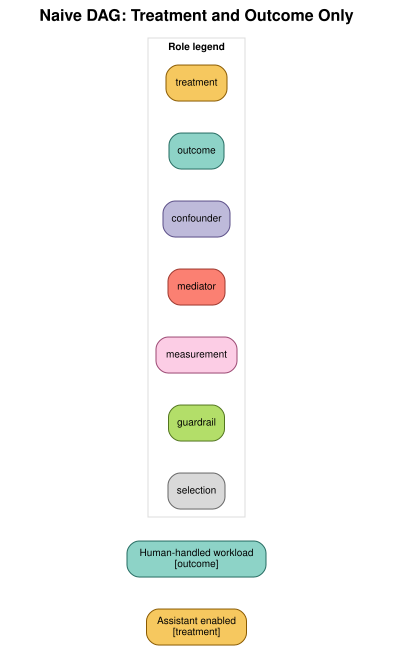

In [12]:
def subset_brainstorm(brainstorm, graph_id, node_ids, edge_pairs, adjustment_candidates=None, forbidden_controls=None):
    node_ids = set(node_ids)
    edge_pairs = set(edge_pairs)
    record = brainstorm.model_dump()
    record['graph_id'] = graph_id
    record['nodes'] = [node for node in record['nodes'] if node['node_id'] in node_ids]
    record['edges'] = [edge for edge in record['edges'] if (edge['source'], edge['target']) in edge_pairs]
    record['adjustment_candidates'] = adjustment_candidates or []
    record['forbidden_controls'] = forbidden_controls or []
    return DAGBrainstorm.model_validate(record)

naive_dag = subset_brainstorm(
    manual_dag,
    'naive_treatment_outcome_dag',
    ['assistant_enabled', 'human_handled_workload'],
    [('assistant_enabled', 'human_handled_workload')],
)

bad_control_dag = subset_brainstorm(
    manual_dag,
    'bad_control_dag',
    ['queue_volume', 'operational_readiness', 'assistant_enabled', 'agent_adoption', 'ticket_deflection', 'human_handled_workload'],
    [
        ('queue_volume', 'assistant_enabled'),
        ('queue_volume', 'human_handled_workload'),
        ('operational_readiness', 'assistant_enabled'),
        ('operational_readiness', 'human_handled_workload'),
        ('assistant_enabled', 'agent_adoption'),
        ('assistant_enabled', 'ticket_deflection'),
        ('agent_adoption', 'human_handled_workload'),
        ('ticket_deflection', 'human_handled_workload'),
    ],
    adjustment_candidates=['queue_volume', 'operational_readiness', 'agent_adoption', 'ticket_deflection'],
    forbidden_controls=['agent_adoption', 'ticket_deflection'],
)

render_dag(naive_dag, title='Naive DAG: Treatment and Outcome Only')


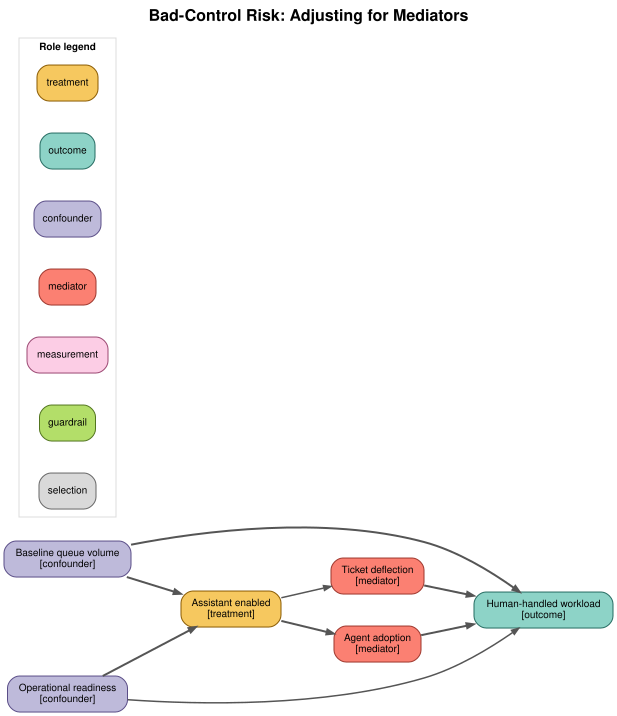

In [13]:
render_dag(bad_control_dag, title='Bad-Control Risk: Adjusting for Mediators')


### Discussion

The naive DAG is easy to draw and easy to believe, but it hides the operational targeting process. If high-volume and ready queues were more likely to receive the assistant, then a simple treated-versus-untreated comparison is not credible.

The bad-control DAG goes too far in the other direction. It includes post-treatment adoption and deflection. Those variables are mechanisms through which enablement may affect workload. If the target estimand is the total effect of enabling the assistant, adjusting for those mediators blocks part of the effect we are trying to estimate.


## 10. Code Example: Why Brainstormed Confounders Matter


In [14]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

rng = np.random.default_rng(SEED)
n = 18000
queue_volume = rng.normal(0, 1, n)
operational_readiness = rng.normal(0, 1, n)
staffing_level = rng.normal(0, 1, n)
baseline_backlog = 0.55 * queue_volume - 0.35 * staffing_level + rng.normal(0, 0.8, n)
queue_complexity = rng.normal(0, 1, n)
routing_change = rng.binomial(1, sigmoid(-0.25 + 0.35 * queue_volume + 0.2 * queue_complexity), n)

propensity = sigmoid(-0.25 + 0.75 * queue_volume + 0.85 * operational_readiness + 0.25 * staffing_level + 0.35 * baseline_backlog + 0.25 * routing_change)
assistant_enabled = rng.binomial(1, propensity)
agent_adoption = 0.75 * assistant_enabled + 0.35 * operational_readiness + 0.15 * staffing_level + rng.normal(0, 0.7, n)
ticket_deflection = 0.55 * assistant_enabled + 0.45 * agent_adoption + 0.2 * queue_volume + rng.normal(0, 0.7, n)

true_direct_effect = -0.55
adoption_effect_of_treatment = 0.75
deflection_direct_effect_of_treatment = 0.55
deflection_effect_of_adoption = 0.45

true_total_effect = (
    true_direct_effect
    - 0.25 * adoption_effect_of_treatment
    - 0.35 * (deflection_direct_effect_of_treatment + deflection_effect_of_adoption * adoption_effect_of_treatment)
)

human_handled_workload = (
    3.0
    + true_direct_effect * assistant_enabled
    + 0.9 * queue_volume
    - 0.25 * operational_readiness
    - 0.45 * staffing_level
    + 0.55 * baseline_backlog
    + 0.45 * queue_complexity
    + 0.35 * routing_change
    - 0.25 * agent_adoption
    - 0.35 * ticket_deflection
    + rng.normal(0, 1.0, n)
)

sim_df = pd.DataFrame(
    {
        'queue_volume': queue_volume,
        'operational_readiness': operational_readiness,
        'staffing_level': staffing_level,
        'baseline_backlog': baseline_backlog,
        'queue_complexity': queue_complexity,
        'routing_change': routing_change,
        'propensity': propensity,
        'assistant_enabled': assistant_enabled,
        'agent_adoption': agent_adoption,
        'ticket_deflection': ticket_deflection,
        'human_handled_workload': human_handled_workload,
    }
)

sim_df.head()


,queue_volume,operational_readiness,staffing_level,baseline_backlog,queue_complexity,routing_change,propensity,assistant_enabled,agent_adoption,ticket_deflection,human_handled_workload
0,0.305,0.636,0.024,-0.481,-0.966,0,0.588,1,1.451,0.961,0.273
1,-1.040,1.580,0.587,-1.630,-0.901,0,0.472,1,0.388,2.067,-0.139
2,0.750,-0.669,0.016,0.179,0.513,1,0.515,1,0.814,2.495,3.454
3,0.941,-0.545,-0.182,1.351,0.732,1,0.661,0,1.372,1.196,5.508
4,-1.951,-0.209,0.027,-0.946,1.735,0,0.098,0,-0.307,-0.615,2.703


In [15]:
def ols_coefficient_table(df, outcome, treatment, covariates):
    columns = [treatment] + covariates
    x = df[columns].to_numpy(dtype=float)
    x = np.column_stack([np.ones(len(df)), x])
    y = df[outcome].to_numpy(dtype=float)
    beta, *_ = np.linalg.lstsq(x, y, rcond=None)
    residuals = y - x @ beta
    dof = len(y) - x.shape[1]
    sigma2 = residuals.T @ residuals / dof
    cov_beta = sigma2 * np.linalg.inv(x.T @ x)
    se = np.sqrt(np.diag(cov_beta))
    treatment_idx = columns.index(treatment) + 1
    return beta[treatment_idx], se[treatment_idx]

models = [
    ('Naive comparison', []),
    ('Adjust pre-treatment confounders', ['queue_volume', 'operational_readiness', 'staffing_level', 'baseline_backlog', 'queue_complexity', 'routing_change']),
    ('Bad control: add mediators', ['queue_volume', 'operational_readiness', 'staffing_level', 'baseline_backlog', 'queue_complexity', 'routing_change', 'agent_adoption', 'ticket_deflection']),
]
rows = []
for label, covariates in models:
    estimate, se = ols_coefficient_table(sim_df, 'human_handled_workload', 'assistant_enabled', covariates)
    rows.append({'model': label, 'estimate': estimate, 'std_error': se, 'covariates': ', '.join(covariates) if covariates else 'none'})
coef_table = pd.DataFrame(rows)
coef_table['true_total_effect'] = true_total_effect
coef_table['bias'] = coef_table['estimate'] - true_total_effect
coef_table


,model,estimate,std_error,covariates,true_total_effect,bias
0,Naive comparison,-0.383,0.028,none,-1.048,0.666
1,Adjust pre-treatment confounders,-1.043,0.018,"queue_volume, operational_readiness, staffing_level, baseline_backlog, queue_complexity, routing_change",-1.048,0.005
2,Bad control: add mediators,-0.531,0.020,"queue_volume, operational_readiness, staffing_level, baseline_backlog, queue_complexity, routing_change, agent_adoption, ticket_deflection",-1.048,0.517


/tmp/ipykernel_178016/4189544279.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_df, y='model', x='estimate', join=False, color='#4776A6')


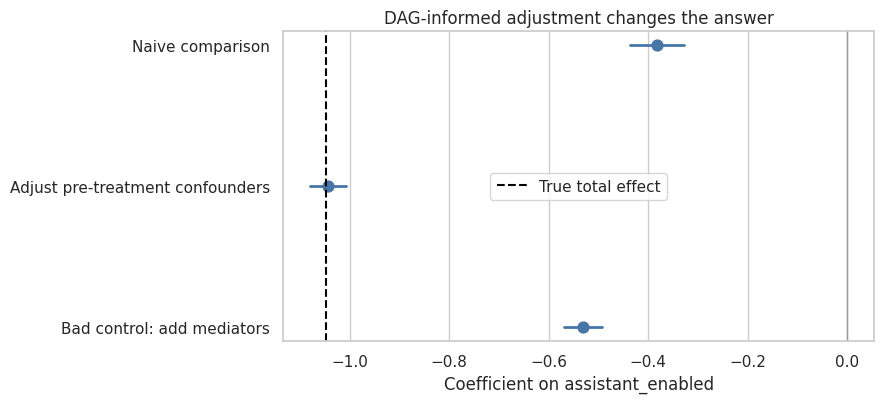

In [16]:
plt.figure(figsize=(9, 4.2))
plot_df = coef_table.copy()
sns.pointplot(data=plot_df, y='model', x='estimate', join=False, color='#4776A6')
for idx, row in plot_df.iterrows():
    plt.plot([row['estimate'] - 1.96 * row['std_error'], row['estimate'] + 1.96 * row['std_error']], [idx, idx], color='#4776A6', linewidth=2)
plt.axvline(true_total_effect, color='black', linestyle='--', label='True total effect')
plt.axvline(0, color='#999999', linewidth=1)
plt.xlabel('Coefficient on assistant_enabled')
plt.ylabel('')
plt.title('DAG-informed adjustment changes the answer')
plt.legend()
plt.tight_layout()
plt.show()


### Discussion

The naive comparison is biased because treatment assignment is not random. High-volume, ready, backlogged queues are more likely to receive the assistant and also have different workload trajectories.

The pre-treatment adjustment model is close to the true total effect because it adjusts for common causes of assistant enablement and workload while leaving the post-treatment pathways open.

The bad-control model adds agent adoption and ticket deflection. Those are post-treatment mechanisms. If the target is the total effect of enabling the assistant, controlling for them blocks part of the treatment effect. In this simulation, the bad-control model moves toward the direct effect of enablement rather than the total effect of enablement.


## 11. AI-Assisted DAG Brainstorming Pattern

Now we wrap the same idea in a local LLM workflow. The model receives a project brief and returns a structured DAG brainstorm. We validate the structure, render the graph, and review it.

For public rendering, live generation stays off. Set `RUN_LIVE_LOCAL_LLM = True` when working interactively on the GPU machine.


In [17]:
from pathlib import Path
import sys


def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    DEFAULT_MODELS_TO_COMPARE,
    build_chat_inputs,
    clean_generated_text,
    clear_loaded_model_cache,
    decode_generated_response,
    format_chat_prompt,
    get_device,
    has_package,
    load_local_model as _shared_load_local_model,
    local_chat as _shared_local_chat,
    move_inputs_to_model_device,
    prepare_chat_inputs,
    set_generation_seed,
)

DEVICE = get_device()


def load_local_model(model_id=MODEL_ID):
    return _shared_load_local_model(model_id)


def decode_generated_text(tokenizer, generated, prompt_token_count, model_id=MODEL_ID):
    return decode_generated_response(tokenizer, generated, prompt_token_count, model_id=model_id)


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    enabled = globals().get('RUN_LIVE_LOCAL_LLM', globals().get('RUN_LOCAL_LLM', True))
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=globals().get('SEED', 123),
        enabled=enabled,
    )


def local_generate(user_message, system_message=None, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=MODEL_ID,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=globals().get('SEED', 123),
        enabled=globals().get('RUN_LOCAL_LLM', globals().get('RUN_LIVE_LOCAL_LLM', True)),
    )


In [18]:
SYSTEM_DAG_MESSAGE = textwrap.dedent(
    '''
    You are a careful causal inference assistant.
    Brainstorm candidate DAGs from project briefs.
    Treat the DAG as a hypothesis to review, not a final truth.
    Preserve temporal ordering. Do not answer whether the treatment worked.
    Return valid JSON only when asked for JSON.
    '''
).strip()

DAG_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Draft a candidate DAG brainstorm for this causal project brief.

    Graph ID: ai_support_dag_brainstorm_v1
    Project question: What is the causal effect of enabling the AI support assistant on human-handled ticket workload?
    Treatment node: assistant_enabled
    Outcome node: human_handled_workload

    Project brief:
    {project_brief}

    Return valid JSON only with exactly these keys:
    graph_id, project_question, treatment_node, outcome_node, nodes, edges,
    adjustment_candidates, forbidden_controls, unresolved_questions, assumptions_to_review.

    Use 8 to 10 nodes and 10 to 14 edges. Keep descriptions concise.
    nodes must be an array of objects with keys: node_id, label, role, timing, observed, description.
    role must be exactly one of: treatment, outcome, confounder, mediator, collider, selection, instrument, guardrail, measurement, post_treatment, context, unknown.
    edges must be an array of objects with keys: source, target, rationale, confidence.
    confidence must be low, medium, or high.
    Include pre-treatment causes of treatment and outcome, but do not include every possible variable.
    Put post-treatment mediators and guardrails in forbidden_controls when estimating the total effect.
    Include unresolved questions for domain experts.
    Do not include directed cycles.
    '''
).strip()

FALLBACK_DAG_JSON = json.dumps(manual_dag.model_dump(), indent=2)


def dag_prompt(project_brief=project_brief):
    return DAG_PROMPT_TEMPLATE.format(project_brief=project_brief)


def dag_brainstorm_llm(model_id=MODEL_ID):
    if RUN_LIVE_LOCAL_LLM:
        return local_chat(dag_prompt(), system_message=SYSTEM_DAG_MESSAGE, model_id=model_id, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE)
    return FALLBACK_DAG_JSON

raw_dag_brainstorm = dag_brainstorm_llm()
print(raw_dag_brainstorm[:1600])


```json
{
 "graph_id": "ai_support_dag_brainstorm_v1",
 "project_question": "What is the causal effect of enabling the AI support assistant on human-handled ticket workload?",
 "treatment_node": "assistant_enabled",
 "outcome_node": "human_handled_workload",
 "nodes": [
 {
 "node_id": "queue_volume",
 "label": "Queue Volume",
 "role": "confounder",
 "timing": "pre-treatment",
 "observed": true,
 "description": "Baseline number of tickets per queue."
 },
 {
 "node_id": "operational_readiness",
 "label": "Operational Readiness",
 "role": "confounder",
 "timing": "pre-treatment",
 "observed": true,
 "description": "Level of preparedness for AI integration."
 },
 {
 "node_id": "manager_request",
 "label": "Manager Request",
 "role": "selection",
 "timing": "pre-treatment",
 "observed": true,
 "description": "Whether managers requested the AI assistant."
 },
 {
 "node_id": "ticket_deflection",
 "label": "Ticket Deflection",
 "role": "mediator",
 "timing": "post-treatment",
 "observed": true

## 12. Parsing and Normalizing DAG Brainstorms


In [19]:
ROLE_MAP = {
    'cause': 'confounder', 'common cause': 'confounder', 'pre treatment confounder': 'confounder',
    'pre-treatment confounder': 'confounder', 'post treatment': 'post_treatment', 'post-treatment': 'post_treatment',
    'bad control': 'post_treatment', 'measurement variable': 'measurement', 'guardrail outcome': 'guardrail',
    'primary outcome': 'outcome', 'exposure': 'treatment',
}


def extract_json_object(text):
    cleaned = clean_generated_text(text)
    cleaned = re.sub(r'^```(?:json)?\s*', '', cleaned.strip())
    cleaned = re.sub(r'\s*```$', '', cleaned.strip())
    start = cleaned.find('{')
    end = cleaned.rfind('}')
    if start == -1 or end == -1 or end <= start:
        return None
    return cleaned[start : end + 1]


def node_id_from_text(value):
    value = clean_generated_text(value)
    value = re.sub(r'[^a-zA-Z0-9_]+', '_', value.strip().lower())
    return re.sub(r'_+', '_', value).strip('_') or 'unknown_node'


def normalize_role(value):
    role = clean_generated_text(value).strip().lower().replace('-', '_').replace(' ', '_')
    readable = role.replace('_', ' ')
    if role in NODE_ROLES:
        return role, []
    if readable in ROLE_MAP:
        return ROLE_MAP[readable], [f'normalized role {value!r} to {ROLE_MAP[readable]!r}']
    if 'mediator' in role:
        return 'mediator', [f'normalized role {value!r} to mediator']
    if 'confound' in role:
        return 'confounder', [f'normalized role {value!r} to confounder']
    if 'outcome' in role:
        return 'outcome', [f'normalized role {value!r} to outcome']
    if 'treat' in role or 'exposure' in role:
        return 'treatment', [f'normalized role {value!r} to treatment']
    if 'guard' in role:
        return 'guardrail', [f'normalized role {value!r} to guardrail']
    return 'unknown', [f'normalized unknown role {value!r} to unknown']


def normalize_confidence(value):
    confidence = clean_generated_text(value).strip().lower()
    if confidence in EDGE_CONFIDENCE:
        return confidence, []
    if confidence in {'certain', 'strong'}:
        return 'high', [f'normalized confidence {value!r} to high']
    if confidence in {'uncertain', 'weak'}:
        return 'low', [f'normalized confidence {value!r} to low']
    return 'medium', [f'normalized confidence {value!r} to medium']


def coerce_string_list(value):
    if value is None:
        return []
    if isinstance(value, list):
        items = value
    elif isinstance(value, str):
        items = re.split(r';|\n', value) if (';' in value or '\n' in value) else [value]
    else:
        items = [value]
    normalized = []
    for item in items:
        if isinstance(item, dict):
            normalized.append(item.get('node_id') or item.get('name') or item.get('label') or json.dumps(item))
        else:
            normalized.append(clean_generated_text(item))
    return [item for item in normalized if item]


def normalize_nodes(value):
    notes = []
    if isinstance(value, dict):
        value = [{'node_id': key, **(val if isinstance(val, dict) else {'description': val})} for key, val in value.items()]
        notes.append('coerced nodes from object mapping to list')
    if not isinstance(value, list):
        value = []
        notes.append('coerced invalid nodes value to empty list')
    nodes = []
    for idx, item in enumerate(value):
        if isinstance(item, str):
            item = {'node_id': node_id_from_text(item), 'label': item, 'role': 'unknown', 'timing': 'unknown', 'observed': 'unknown', 'description': item}
            notes.append(f'coerced nodes[{idx}] from string to object')
        else:
            item = dict(item)
        item.setdefault('node_id', node_id_from_text(item.get('label') or item.get('name') or f'node_{idx}'))
        item.setdefault('label', item.get('name') or item['node_id'])
        item.setdefault('role', 'unknown')
        item.setdefault('timing', 'unknown')
        item.setdefault('observed', 'unknown')
        item.setdefault('description', item.get('label', item['node_id']))
        item['node_id'] = node_id_from_text(item['node_id'])
        role, role_notes = normalize_role(item['role'])
        item['role'] = role
        notes.extend(f'nodes[{idx}]: {note}' for note in role_notes)
        for field in ['label', 'timing', 'description']:
            if not isinstance(item[field], str):
                item[field] = clean_generated_text(item[field])
                notes.append(f'coerced nodes[{idx}].{field} to string')
        nodes.append(item)
    return nodes, notes


def normalize_edges(value):
    notes = []
    if isinstance(value, dict):
        value = value.get('edges', value.get('links', []))
        notes.append('coerced edges from object to contained edge list')
    if not isinstance(value, list):
        value = []
        notes.append('coerced invalid edges value to empty list')
    edges = []
    for idx, item in enumerate(value):
        if isinstance(item, str):
            parts = re.split(r'->|→| to ', item, maxsplit=1)
            item = {'source': parts[0].strip(), 'target': parts[1].strip() if len(parts) > 1 else f'unknown_target_{idx}', 'rationale': item, 'confidence': 'medium'}
            notes.append(f'coerced edges[{idx}] from string to object')
        else:
            item = dict(item)
        item.setdefault('source', item.get('from') or item.get('cause') or item.get('parent') or '')
        item.setdefault('target', item.get('to') or item.get('effect') or item.get('child') or '')
        item.setdefault('rationale', item.get('reason') or item.get('description') or 'candidate causal link')
        item.setdefault('confidence', 'medium')
        item['source'] = node_id_from_text(item['source'])
        item['target'] = node_id_from_text(item['target'])
        item['rationale'] = clean_generated_text(item['rationale'])
        confidence, confidence_notes = normalize_confidence(item['confidence'])
        item['confidence'] = confidence
        notes.extend(f'edges[{idx}]: {note}' for note in confidence_notes)
        if item['source'] and item['target'] and item['source'] != item['target']:
            edges.append(item)
    return edges, notes


def coerce_dag_brainstorm(candidate):
    data = json.loads(candidate)
    notes = []
    for field in ['graph_id', 'project_question', 'treatment_node', 'outcome_node']:
        if field not in data or not data[field]:
            data[field] = 'unknown' if field != 'graph_id' else 'dag_brainstorm'
            notes.append(f'filled missing {field}')
        data[field] = clean_generated_text(data[field])
    data['treatment_node'] = node_id_from_text(data['treatment_node'])
    data['outcome_node'] = node_id_from_text(data['outcome_node'])
    nodes, node_notes = normalize_nodes(data.get('nodes', []))
    edges, edge_notes = normalize_edges(data.get('edges', []))
    notes.extend(node_notes + edge_notes)
    existing = {node['node_id'] for node in nodes}
    for node_id, role, label in [(data['treatment_node'], 'treatment', 'Treatment'), (data['outcome_node'], 'outcome', 'Outcome')]:
        if node_id not in existing:
            nodes.append({'node_id': node_id, 'label': label, 'role': role, 'timing': role, 'observed': 'unknown', 'description': f'Auto-filled {role} node from graph metadata.'})
            notes.append(f'auto-filled missing {role} node {node_id!r}')
    data['nodes'] = nodes
    data['edges'] = edges
    for field in ['adjustment_candidates', 'forbidden_controls', 'unresolved_questions', 'assumptions_to_review']:
        data[field] = coerce_string_list(data.get(field, []))
        if field in {'adjustment_candidates', 'forbidden_controls'}:
            data[field] = [node_id_from_text(item) for item in data[field]]
    return json.dumps(data), notes


def parse_dag_brainstorm(raw_output):
    candidates = [clean_generated_text(raw_output)]
    extracted = extract_json_object(raw_output)
    if extracted is not None and extracted not in candidates:
        candidates.append(extracted)
    errors = []
    for candidate in candidates:
        try:
            return DAGBrainstorm.model_validate_json(candidate), candidate, errors
        except ValidationError as error:
            errors.append(error.errors()[0]['msg'])
        except ValueError as error:
            errors.append(str(error).splitlines()[0])
        try:
            repaired_candidate, repair_notes = coerce_dag_brainstorm(candidate)
            return DAGBrainstorm.model_validate_json(repaired_candidate), repaired_candidate, errors + repair_notes
        except (TypeError, json.JSONDecodeError, ValidationError) as error:
            errors.append(str(error).splitlines()[0])
    raise ValueError(f'No valid DAGBrainstorm found. Parser errors: {errors}')

SINGLE_DAG_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    The previous answer could not be parsed as a complete DAGBrainstorm JSON object.
    It may have been truncated. Reconstruct a complete, valid JSON object for the same project brief.

    Use 8 to 10 nodes and 10 to 14 edges. Keep descriptions concise.
    Do not add a prose explanation. Return JSON only.
    Preserve graph_id, treatment_node, and outcome_node.
    Role values must use the allowed role list.
    Edge confidence must be low, medium, or high.

    Parser error:
    {error_message}

    Project brief:
    {project_brief}

    Previous partial answer:
    {raw_output}
    '''
).strip()


def parse_or_repair_single_dag(raw_output, model_id=MODEL_ID):
    try:
        parsed, parsed_json, notes = parse_dag_brainstorm(raw_output)
        return parsed, parsed_json, notes, ''
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise

        repair_prompt = SINGLE_DAG_REPAIR_PROMPT_TEMPLATE.format(
            error_message=clean_generated_text(repr(first_error))[:1200],
            project_brief=project_brief,
            raw_output=clean_generated_text(raw_output)[:5000],
        )
        repaired_raw_output = local_chat(
            repair_prompt,
            system_message=SYSTEM_DAG_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed, parsed_json, notes = parse_dag_brainstorm(repaired_raw_output)
        return parsed, parsed_json, [f'first_parse_error: {type(first_error).__name__}'] + notes, repaired_raw_output


parsed_ai_dag, json_used, parser_notes, repaired_raw_dag = parse_or_repair_single_dag(raw_dag_brainstorm)
if parser_notes:
    print('Parser notes:')
    print(parser_notes[:12])

parsed_ai_dag


Parser notes:
['Invalid JSON: expected value at line 1 column 1', 'Expecting value: line 1 column 1 (char 0)']


DAGBrainstorm(graph_id='ai_support_dag_brainstorm_v1', project_question='What is the causal effect of enabling the AI support assistant on human-handled ticket workload?', treatment_node='assistant_enabled', outcome_node='human_handled_workload', nodes=[DAGNode(node_id='queue_volume', label='Queue Volume', role='confounder', timing='pre-treatment', observed=True, description='Baseline number of tickets per queue.'), DAGNode(node_id='operational_readiness', label='Operational Readiness', role='confounder', timing='pre-treatment', observed=True, description='Level of preparedness for AI integration.'), DAGNode(node_id='manager_request', label='Manager Request', role='selection', timing='pre-treatment', observed=True, description='Whether managers requested the AI assistant.'), DAGNode(node_id='ticket_deflection', label='Ticket Deflection', role='mediator', timing='post-treatment', observed=True, description='Number of tickets handled by the AI before human intervention.'), DAGNode(node_i

## 13. Review the AI-Drafted DAG


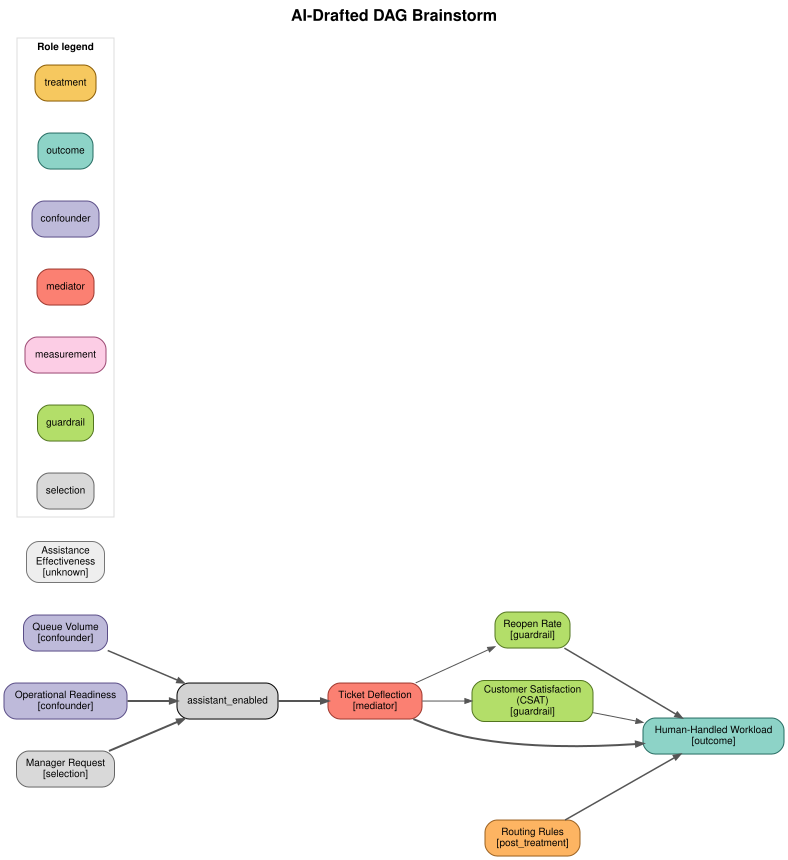

In [20]:
render_dag(parsed_ai_dag, title='AI-Drafted DAG Brainstorm')


In [21]:
ai_checks, ai_graph, ai_edge_errors = graph_quality_checks(parsed_ai_dag)
ai_review = pd.DataFrame([{'check': key, 'passed': value} for key, value in ai_checks.items()])
ai_review


,check,passed
0,has treatment node,True
1,has outcome node,True
2,is acyclic,True
3,all edge endpoints exist,True
4,has treatment to outcome path,True
5,has at least two adjustment candidates,True
6,forbidden controls include post-treatment variables,True
7,has unresolved questions,True


In [22]:
def semantic_dag_audit(brainstorm):
    roles = {node.node_id: node.role for node in brainstorm.nodes}
    graph = to_networkx(brainstorm)
    issues = []
    for var in brainstorm.adjustment_candidates:
        role = roles.get(var, 'missing')
        if role in {'mediator', 'measurement', 'guardrail', 'post_treatment', 'outcome', 'treatment'}:
            issues.append(('adjustment_candidates', var, f'{role} should not be a routine adjustment variable for a total-effect estimand'))
        if var not in roles:
            issues.append(('adjustment_candidates', var, 'variable not found among DAG nodes'))
    for var in brainstorm.forbidden_controls:
        if var not in roles:
            issues.append(('forbidden_controls', var, 'variable not found among DAG nodes'))
    if nx.is_directed_acyclic_graph(graph):
        for var, role in roles.items():
            if role in {'mediator', 'measurement'} and nx.has_path(graph, brainstorm.treatment_node, var) and var not in brainstorm.forbidden_controls:
                issues.append(('forbidden_controls', var, 'post-treatment pathway variable should be listed as a forbidden control'))
    else:
        issues.append(('graph_structure', brainstorm.graph_id, 'graph contains a directed cycle'))
    return pd.DataFrame(issues, columns=['area', 'variable', 'issue'])

semantic_dag_audit(parsed_ai_dag)


,area,variable,issue
0,adjustment_candidates,routing_rules,post_treatment should not be a routine adjustment variable for a total-effect estimand


### Discussion

The AI-drafted DAG is a brainstorming artifact. A clean parser result means the graph is machine-readable. It does not mean the graph is causally correct.

The semantic audit checks common mistakes: adjustment sets that include post-treatment variables, forbidden controls that are missing from the node list, and mediator-like variables that were not marked as forbidden for a total-effect estimand.


## 14. Optional All-Model Comparison

Because these are live local model calls, the exact ranking may change across model versions, package versions, seeds, tokenizer behavior, prompt wording, and reruns. The durable lesson is the evaluation pattern, not the leaderboard. Treat each table as an empirical snapshot of model behavior under this workflow.


As before, we compare all available local models when the task is model-sensitive. For DAG brainstorming, the comparison asks whether each model can return a structured, acyclic, reviewable graph artifact.

Keep the switches off for public rendering. Turn them on only in an interactive GPU session:

```python
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
```

In [23]:
SUMMARY_COLUMNS = ['label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases', 'schema_reliability', 'mean_dag_score', 'failure_types']
CASE_RESULT_COLUMNS = ['label', 'model_id', 'role', 'case_id', 'status', 'schema_valid', 'repair_used', 'repair_stage', 'error_type', 'dag_score', 'max_dag_score', 'dag_score_share', 'error']

SCHEMA_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required DAGBrainstorm JSON schema.
    Convert the previous answer into valid JSON only.
    Do not add new causal claims. Preserve graph_id, treatment_node, and outcome_node when possible.
    nodes and edges must be arrays of objects. Role values must use the allowed role list.
    Edge confidence must be low, medium, or high.

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def classify_structured_output_failure(error):
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_extra_text'
    return 'other_structured_output_error'


def build_schema_repair_prompt(raw_output, error_message):
    return SCHEMA_REPAIR_PROMPT_TEMPLATE.format(raw_output=clean_generated_text(raw_output)[:6000], error_message=clean_generated_text(error_message)[:1200])


def parse_or_repair_dag(raw_output, model_id):
    if not clean_generated_text(raw_output):
        raise ValueError('empty model output')
    try:
        parsed, parsed_json, notes = parse_dag_brainstorm(raw_output)
        return {'parsed': parsed, 'parsed_json': parsed_json, 'parser_notes': notes, 'repair_used': bool(notes), 'repair_stage': 'parser' if notes else 'none', 'repaired_raw_output': ''}
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise
        repaired_raw_output = local_chat(build_schema_repair_prompt(raw_output, repr(first_error)), system_message=SYSTEM_DAG_MESSAGE, model_id=model_id, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE)
        parsed, parsed_json, notes = parse_dag_brainstorm(repaired_raw_output)
        return {'parsed': parsed, 'parsed_json': parsed_json, 'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + notes, 'repair_used': True, 'repair_stage': 'model_retry', 'repaired_raw_output': repaired_raw_output}


def score_dag_brainstorm(brainstorm):
    checks, graph, _ = graph_quality_checks(brainstorm)
    roles = {node.node_id: node.role for node in brainstorm.nodes}
    extra_checks = {
        'has at least eight nodes': len(brainstorm.nodes) >= 8,
        'has at least eight edges': len(brainstorm.edges) >= 8,
        'has confounders': sum(role == 'confounder' for role in roles.values()) >= 2,
        'has mediator or measurement pathway': any(role in {'mediator', 'measurement'} for role in roles.values()),
        'has guardrail outcome': any(role == 'guardrail' for role in roles.values()),
        'has assumptions to review': len(brainstorm.assumptions_to_review) >= 2,
    }
    all_checks = checks | extra_checks
    return int(sum(all_checks.values())), len(all_checks), all_checks


def evaluate_model_on_dag_case(label, model_id, role):
    raw_output = repaired_raw_output = parsed_json = ''
    parser_notes = []
    checks = {}
    error = error_type = ''
    schema_valid = repair_used = False
    repair_stage = 'none'
    dag_score = np.nan
    max_dag_score = 14
    try:
        raw_output = local_chat(dag_prompt(), system_message=SYSTEM_DAG_MESSAGE, model_id=model_id, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE)
        parse_result = parse_or_repair_dag(raw_output, model_id)
        parsed = parse_result['parsed']
        parsed_json = parse_result['parsed_json']
        parser_notes = parse_result['parser_notes']
        repair_used = parse_result['repair_used']
        repair_stage = parse_result['repair_stage']
        repaired_raw_output = parse_result['repaired_raw_output']
        dag_score, max_dag_score, checks = score_dag_brainstorm(parsed)
        status = 'ok_after_repair' if repair_used else 'ok'
        schema_valid = True
        error_type = 'none'
    except Exception as exc:
        status = 'schema_error'
        error = repr(exc)[:500]
        error_type = classify_structured_output_failure(exc)
    row = {'label': label, 'model_id': model_id, 'role': role, 'case_id': 'ai_support_dag_brainstorm_v1', 'status': status, 'schema_valid': schema_valid, 'repair_used': repair_used, 'repair_stage': repair_stage, 'error_type': error_type, 'dag_score': dag_score, 'max_dag_score': max_dag_score, 'dag_score_share': dag_score / max_dag_score if pd.notna(dag_score) else 0.0, 'error': error}
    artifact = {'raw_output': raw_output, 'repaired_raw_output': repaired_raw_output, 'parsed_json': parsed_json, 'parser_notes': parser_notes, 'checks': checks}
    clear_loaded_model_cache()
    return row, artifact


def summarize_model_results(case_results):
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    model_summary = case_results.groupby(['label', 'model_id', 'role'], dropna=False).agg(cases=('case_id', 'count'), schema_valid_cases=('schema_valid', 'sum'), schema_repaired_cases=('repair_used', 'sum'), mean_dag_score=('dag_score_share', lambda s: s.fillna(0).mean()), failure_types=('error_type', lambda s: ', '.join(sorted({str(x) for x in s if str(x) and str(x) != 'none'})))).reset_index()
    model_summary['schema_reliability'] = model_summary['schema_valid_cases'] / model_summary['cases']
    return model_summary[SUMMARY_COLUMNS].sort_values(['schema_reliability', 'mean_dag_score', 'schema_repaired_cases'], ascending=[False, False, True])


def run_all_model_dag_comparison(models_to_compare=MODELS_TO_COMPARE):
    if not RUN_LIVE_LOCAL_LLM:
        raise RuntimeError('Set RUN_LIVE_LOCAL_LLM = True before running the model comparison.')
    rows = []
    artifacts = {}
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        row, artifact = evaluate_model_on_dag_case(label, model_id, role)
        rows.append(row)
        artifacts[label] = artifact
    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS)
    model_summary = summarize_model_results(case_results)
    return case_results, model_summary, artifacts

if RUN_FULL_MODEL_COMPARISON:
    dag_case_results, dag_model_summary, dag_artifacts = run_all_model_dag_comparison()
else:
    dag_model_summary = pd.DataFrame(MODELS_TO_COMPARE, columns=['label', 'model_id', 'role'])
    dag_model_summary['cases'] = 1
    dag_model_summary['schema_valid_cases'] = np.nan
    dag_model_summary['schema_repaired_cases'] = np.nan
    dag_model_summary['schema_reliability'] = np.nan
    dag_model_summary['mean_dag_score'] = np.nan
    dag_model_summary['failure_types'] = ''
    dag_model_summary = dag_model_summary[SUMMARY_COLUMNS]
    dag_case_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS)
    dag_artifacts = {}
    display(Markdown('All-model comparison is configured but not executed. Set `RUN_LIVE_LOCAL_LLM = True` and `RUN_FULL_MODEL_COMPARISON = True` in an interactive GPU session.'))

dag_model_summary


Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct


Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct


Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct


Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


Running Phi mini: microsoft/Phi-3.5-mini-instruct


...

Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it


Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_dag_score,failure_types
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,1,1,1,1.000,1.000,
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,1,1,1,1.000,1.000,
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,1,1,1,1.000,0.929,
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,1,1,1,1.000,0.929,
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,1,1,1,1.000,0.929,
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,1,1,1,1.000,0.929,
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,1,1,1,1.000,0.929,
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,1,1,1,1.000,0.857,
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,1,1,1,1.000,0.500,


### Interpreting Repair Counts

`schema_repaired_cases` should not be read as a simple failure count. In this notebook, repair can mean several different things:

- **Parser cleanup**: the model returned usable JSON inside Markdown fences or used a slightly different label that the parser normalized.
- **Schema repair**: the model returned a structurally close object but used a wrong field shape, role label, or confidence label.
- **Model retry**: the first output was incomplete or invalid enough that we asked the model to reconstruct a valid JSON object.
- **Semantic repair**: the graph is machine-readable, but human review finds a causal issue such as a post-treatment variable in the adjustment set.

Only the last category is a causal-design concern. The first two are often ordinary engineering friction in local LLM workflows.


In [24]:
def summarize_repair_stages(case_results):
    if case_results.empty or 'repair_stage' not in case_results.columns:
        return pd.DataFrame(columns=['repair_stage', 'cases'])
    return (
        case_results.assign(repair_stage=case_results['repair_stage'].fillna('none'))
        .groupby('repair_stage', dropna=False)
        .size()
        .reset_index(name='cases')
        .sort_values('cases', ascending=False)
    )


repair_stage_summary = summarize_repair_stages(dag_case_results)
repair_stage_summary


,repair_stage,cases
1,parser,8
0,model_retry,1


When the repair stage is `parser`, the model output was usually close enough to recover deterministically. When the repair stage is `model_retry`, the first answer was not usable as a structured artifact and the system needed a second model call. That distinction is important for production workflows because parser cleanup is cheap and predictable, while model retry adds latency, cost, and another opportunity for drift.


## 15. Human Review Checklist


In [25]:
dag_review_checklist = pd.DataFrame(
    [
        ('question', 'Does the graph correspond to the estimand and decision, not a different question?'),
        ('time ordering', 'Do all arrows respect time ordering?'),
        ('treatment', 'Is treatment assignment represented separately from treatment use or adherence?'),
        ('outcome', 'Is the primary outcome separated from guardrails and measurement artifacts?'),
        ('confounding', 'Are plausible common causes of treatment and outcome included?'),
        ('mediators', 'Are post-treatment mechanisms marked as forbidden controls for total effects?'),
        ('selection', 'Does the graph show how units enter the analysis population?'),
        ('measurement', 'Are logging changes and measurement definitions represented explicitly?'),
        ('cycles', 'Is the graph acyclic after temporal ordering is enforced?'),
        ('open questions', 'Does the graph create domain questions to resolve before estimation?'),
    ],
    columns=['area', 'review question'],
)

dag_review_checklist


,area,review question
0,question,"Does the graph correspond to the estimand and decision, not a different question?"
1,time ordering,Do all arrows respect time ordering?
2,treatment,Is treatment assignment represented separately from treatment use or adherence?
3,outcome,Is the primary outcome separated from guardrails and measurement artifacts?
4,confounding,Are plausible common causes of treatment and outcome included?
5,mediators,Are post-treatment mechanisms marked as forbidden controls for total effects?
6,selection,Does the graph show how units enter the analysis population?
7,measurement,Are logging changes and measurement definitions represented explicitly?
8,cycles,Is the graph acyclic after temporal ordering is enforced?
9,open questions,Does the graph create domain questions to resolve before estimation?


## 16. Common AI DAG Brainstorming Failure Modes


In [26]:
dag_failure_patterns = pd.DataFrame(
    [
        ('Fluent but underspecified', 'The model draws treatment -> outcome and skips operational targeting.', 'Ask for pre-treatment causes of both treatment and outcome.'),
        ('Post-treatment adjustment', 'The model recommends controlling for adoption, engagement, deflection, or usage.', 'Mark mediators and measurement changes as forbidden controls for total effects.'),
        ('Temporal reversal', 'The model draws outcome or post-treatment behavior as a cause of assignment.', 'Force each node to include timing relative to treatment.'),
        ('Guardrail confusion', 'The model treats guardrails as confounders or primary outcomes.', 'Separate primary outcome, guardrails, and launch-blocking conditions.'),
        ('Measurement optimism', 'The model assumes observed metrics equal the target construct.', 'Add logging, definitions, and measurement changes as explicit nodes.'),
        ('Overconfident arrows', 'The model presents speculative links as facts.', 'Require confidence labels and unresolved questions.'),
    ],
    columns=['failure mode', 'what it looks like', 'repair prompt'],
)

dag_failure_patterns


,failure mode,what it looks like,repair prompt
0,Fluent but underspecified,The model draws treatment -> outcome and skips operational targeting.,Ask for pre-treatment causes of both treatment and outcome.
1,Post-treatment adjustment,"The model recommends controlling for adoption, engagement, deflection, or usage.",Mark mediators and measurement changes as forbidden controls for total effects.
2,Temporal reversal,The model draws outcome or post-treatment behavior as a cause of assignment.,Force each node to include timing relative to treatment.
3,Guardrail confusion,The model treats guardrails as confounders or primary outcomes.,"Separate primary outcome, guardrails, and launch-blocking conditions."
4,Measurement optimism,The model assumes observed metrics equal the target construct.,"Add logging, definitions, and measurement changes as explicit nodes."
5,Overconfident arrows,The model presents speculative links as facts.,Require confidence labels and unresolved questions.


## 17. Key Takeaways

- DAGs are assumption artifacts, not decorative figures and not automatically discovered truths.
- AI is useful for brainstorming variables, arrows, mechanisms, measurement issues, and unresolved domain questions.
- A useful DAG workflow extracts variables before drawing arrows.
- Time ordering is the main guardrail against many bad DAGs.
- Pre-treatment common causes are adjustment candidates; post-treatment mechanisms are often forbidden controls for total-effect estimands.
- Graphviz DAGs are useful because they make assumptions inspectable and discussable.
- Schema validation makes AI DAG outputs machine-readable, but semantic review decides whether the graph is credible.
- Repair counts should be interpreted by stage: parser cleanup, schema repair, model retry, and semantic repair have different meanings.
- All-model comparison should continue to separate structured-output reliability from causal-design quality.

The next notebook will critique variable roles and backdoor paths more formally.
